# Clasificación multiclase

## Introduction

En este ejercicio se implementa la regresion one-vs-all y una red neuronal para reconocimiento de digitos.

Antes de empezar la ejecución de las partes de codigo correspondienters a los ejercicios, se requiere importar todas las librerias necesarias.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

%matplotlib inline

path = '/content/drive/MyDrive/colab/lab4/'  # cambia si tu ruta es distinta

# Cargar el dataset (un solo CSV con features y etiqueta)
df = pd.read_csv(path + 'covtype.csv')

print("Dimensiones:", df.shape)
print(df.head())

Mounted at /content/drive
Dimensiones: (581012, 55)
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235  

In [2]:
# La última columna es la etiqueta (Cover_Type: clases 1-7)
X = df.drop('Cover_Type', axis=1).to_numpy()
y = df['Cover_Type'].to_numpy()

# Las clases van de 1 a 7, las dejamos así (se maneja en oneVsAll)
print("Clases únicas:", np.unique(y))
print("X shape:", X.shape, "y shape:", y.shape)

# Normalizar features numéricas (importante: mejora convergencia)
# Solo normalizamos, no estandarizamos binarias pero igual aplica bien
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Agregar columna de 1s para el bias (igual que en tu código de MNIST)
X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
print("X con bias:", X.shape)

Clases únicas: [1 2 3 4 5 6 7]
X shape: (581012, 54) y shape: (581012,)
X con bias: (581012, 55)


In [3]:
from sklearn.model_selection import train_test_split

# Primero separamos test (10%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

# Luego separamos validación del restante (20% del total ~22% del trainval)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print("Train:", X_train_split.shape, y_train_split.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (418328, 55) (418328,)
Val:   (104582, 55) (104582,)
Test:  (58102, 55) (58102,)


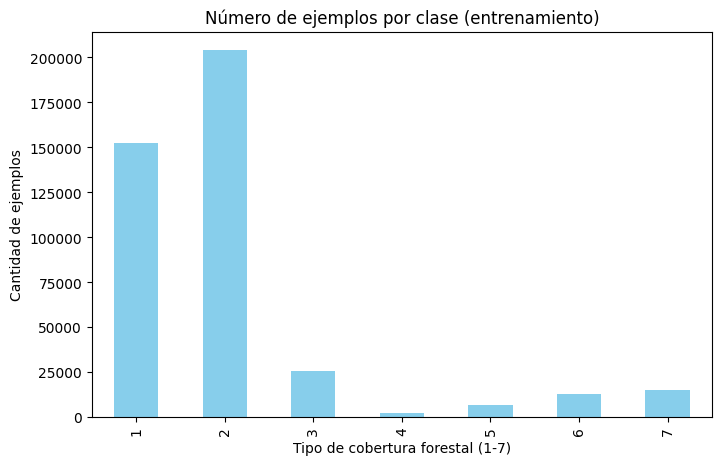

In [4]:
plt.figure(figsize=(8,5))
pd.Series(y_train_split).value_counts().sort_index().plot(
    kind='bar', color='skyblue'
)
plt.title("Número de ejemplos por clase (entrenamiento)")
plt.xlabel("Tipo de cobertura forestal (1-7)")
plt.ylabel("Cantidad de ejemplos")
plt.show()

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def lrCostFunction(theta, X, y, lambda_):
    """
    Costo y gradiente para regresión logística binaria con regularización L2.
    Igual que tu laboratorio de imágenes.
    """
    m = y.size
    h = sigmoid(X.dot(theta))

    temp = theta.copy()
    temp[0] = 0  # no regularizar bias

    J = (1/m) * (-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) \
        + (lambda_ / (2*m)) * np.sum(temp**2)

    grad = (1/m) * (X.T.dot(h - y)) + (lambda_/m) * temp

    return J, grad

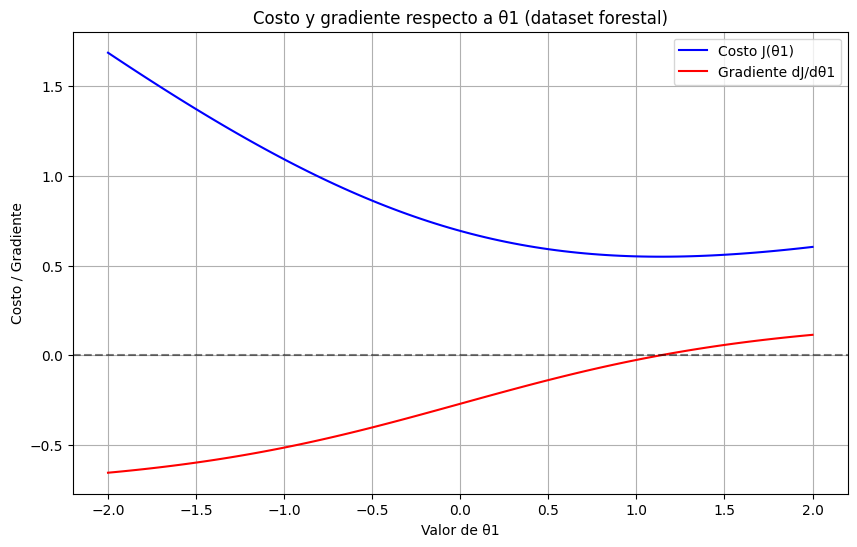

In [11]:
# Tomamos 5 ejemplos y binarizamos para clase 1
X_example = X_train_split[:5]
y_example = (y_train_split[:5] == 1).astype(int)

theta_init = np.zeros(X_example.shape[1])
lambda_ = 0.01

theta_range = np.linspace(-2, 2, 100)
cost_values = []
grad_values = []

for t in theta_range:
    theta_temp = theta_init.copy()
    theta_temp[1] = t
    J, grad = lrCostFunction(theta_temp, X_example, y_example, lambda_)
    cost_values.append(J)
    grad_values.append(grad[1])

plt.figure(figsize=(10,6))
plt.plot(theta_range, cost_values, label="Costo J(θ1)", color='blue')
plt.plot(theta_range, grad_values, label="Gradiente dJ/dθ1", color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel("Valor de θ1")
plt.ylabel("Costo / Gradiente")
plt.title("Costo y gradiente respecto a θ1 (dataset forestal)")
plt.legend()
plt.grid(True)
plt.show()

# Curva azul: costo J(θ1) — convexa, un solo mínimo global
# Curva roja: gradiente — cruza cero donde J es mínimo
# Mismo comportamiento que MNIST: el optimizador sigue el gradiente para bajar el costo

In [12]:
cost_history_all = []

def oneVsAll_with_cost(X, y, num_labels, lambda_):
    """
    Entrena un clasificador binario por cada clase (One-vs-All).
    Las clases en este dataset van de 1 a 7.
    """
    m, n = X.shape
    # Guardamos theta para cada clase en filas
    all_theta = np.zeros((num_labels, n))

    for idx, c in enumerate(range(1, num_labels + 1)):  # clases 1..7
        print(f"Entrenando clase {c} ...")

        initial_theta = np.zeros(n)

        # Binarizar: 1 si es clase c, 0 si no
        y_c = (y == c).astype(int)

        cost_history = []

        def callback(theta):
            J, _ = lrCostFunction(theta, X, y_c, lambda_)
            cost_history.append(J)

        res = optimize.minimize(
            fun=lambda t: lrCostFunction(t, X, y_c, lambda_),
            x0=initial_theta,
            jac=True,
            method='TNC',
            options={'maxiter': 50},
            callback=callback
        )

        all_theta[idx] = res.x
        cost_history_all.append(cost_history)

    return all_theta

num_labels = 7   # 7 tipos de cobertura forestal
lambda_ = 0.1

all_theta = oneVsAll_with_cost(X_train_split, y_train_split, num_labels, lambda_)
print("Entrenamiento completado. all_theta:", all_theta.shape)

Entrenando clase 1 ...


/tmp/ipykernel_1616/4233083562.py:26: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(


Entrenando clase 2 ...
Entrenando clase 3 ...
Entrenando clase 4 ...
Entrenando clase 5 ...
Entrenando clase 6 ...


/tmp/ipykernel_1616/1413225849.py:15: RuntimeWarning: divide by zero encountered in log
  J = (1/m) * (-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) \


Entrenando clase 7 ...
Entrenamiento completado. all_theta: (7, 55)


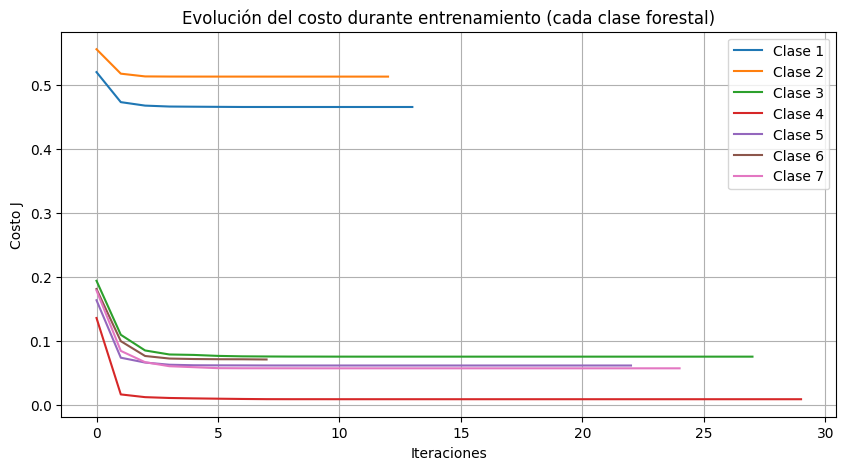

In [13]:
plt.figure(figsize=(10,5))

for i, ch in enumerate(cost_history_all):
    plt.plot(ch, label=f'Clase {i+1}')

plt.xlabel("Iteraciones")
plt.ylabel("Costo J")
plt.title("Evolución del costo durante entrenamiento (cada clase forestal)")
plt.legend()
plt.grid(True)
plt.show()

Precisión entrenamiento: 71.58%
Precisión validación:    71.57%
Precisión test:          71.25%


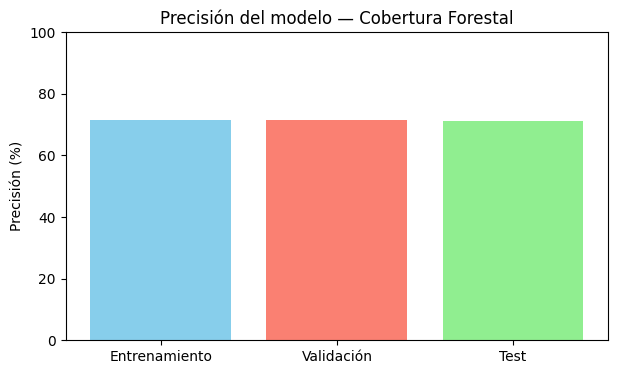

In [14]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve la clase predicha.
    OJO: all_theta[0] corresponde a clase 1, all_theta[1] a clase 2, etc.
    Por eso sumamos 1 al argmax.
    """
    probs = sigmoid(X.dot(all_theta.T))  # probabilidad de cada clase
    p = np.argmax(probs, axis=1) + 1     # +1 porque las clases van de 1 a 7
    return p

pred_train = predictOneVsAll(all_theta, X_train_split)
pred_val   = predictOneVsAll(all_theta, X_val)
pred_test  = predictOneVsAll(all_theta, X_test)

acc_train = np.mean(pred_train == y_train_split) * 100
acc_val   = np.mean(pred_val == y_val) * 100
acc_test  = np.mean(pred_test == y_test) * 100

print(f"Precisión entrenamiento: {acc_train:.2f}%")
print(f"Precisión validación:    {acc_val:.2f}%")
print(f"Precisión test:          {acc_test:.2f}%")

plt.figure(figsize=(7,4))
plt.bar(['Entrenamiento', 'Validación', 'Test'],
        [acc_train, acc_val, acc_test],
        color=['skyblue', 'salmon', 'lightgreen'])
plt.ylim(0, 100)
plt.ylabel("Precisión (%)")
plt.title("Precisión del modelo — Cobertura Forestal")
plt.show()

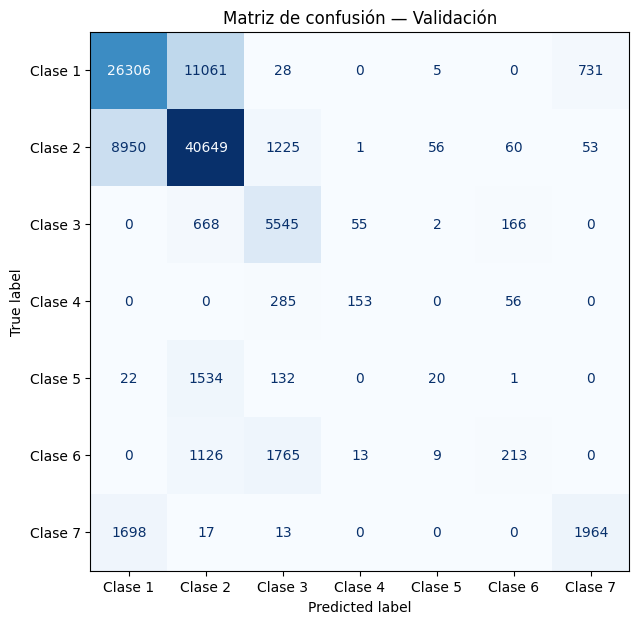

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[f'Clase {i}' for i in range(1,8)])
fig, ax = plt.subplots(figsize=(9,7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Matriz de confusión — Validación")
plt.show()

In [17]:
# ── CELDA 11 — Predicciones reales con ejemplos del test ──────────────────

# Tomamos 2 ejemplos reales del conjunto de test
# Este dataset describe características geográficas de zonas boscosas
# y predecimos qué TIPO DE ÁRBOL (cobertura forestal) predomina en esa zona
# basándonos en: elevación, pendiente, distancia a ríos, sombra, tipo de suelo, etc.

idx1, idx2 = 0, 5  # podés cambiar estos índices

ejemplos = X_test[[idx1, idx2]]
etiquetas_reales = y_test[[idx1, idx2]]

predicciones = predictOneVsAll(all_theta, ejemplos)

# Nombre real de cada clase en español
nombres_clase = {
    1: "Abeto / Pícea",
    2: "Pino lodgepole",
    3: "Pino ponderosa",
    4: "Álamo / Sauce",
    5: "Álamo temblón",
    6: "Abeto Douglas",
    7: "Pino enano (Krummholz)"
}

for i, (pred, real) in enumerate(zip(predicciones, etiquetas_reales)):
    correcto = "CORRECTO" if pred == real else "INCORRECTO"
    print(f"── Ejemplo {i+1} ──────────────────────────────")
    print(f"  Qué predecimos : el tipo de árbol dominante en una parcela de bosque")
    print(f"                   según sus condiciones geográficas y de suelo")
    print(f"  Predicción     : Clase {pred} — {nombres_clase[pred]}")
    print(f"  Valor real     : Clase {real} — {nombres_clase[real]}")
    print(f"  Resultado      : {correcto}")
    print()

── Ejemplo 1 ──────────────────────────────
  Qué predecimos : el tipo de árbol dominante en una parcela de bosque
                   según sus condiciones geográficas y de suelo
  Predicción     : Clase 1 — Abeto / Pícea
  Valor real     : Clase 2 — Pino lodgepole
  Resultado      : INCORRECTO

── Ejemplo 2 ──────────────────────────────
  Qué predecimos : el tipo de árbol dominante en una parcela de bosque
                   según sus condiciones geográficas y de suelo
  Predicción     : Clase 2 — Pino lodgepole
  Valor real     : Clase 1 — Abeto / Pícea
  Resultado      : INCORRECTO

